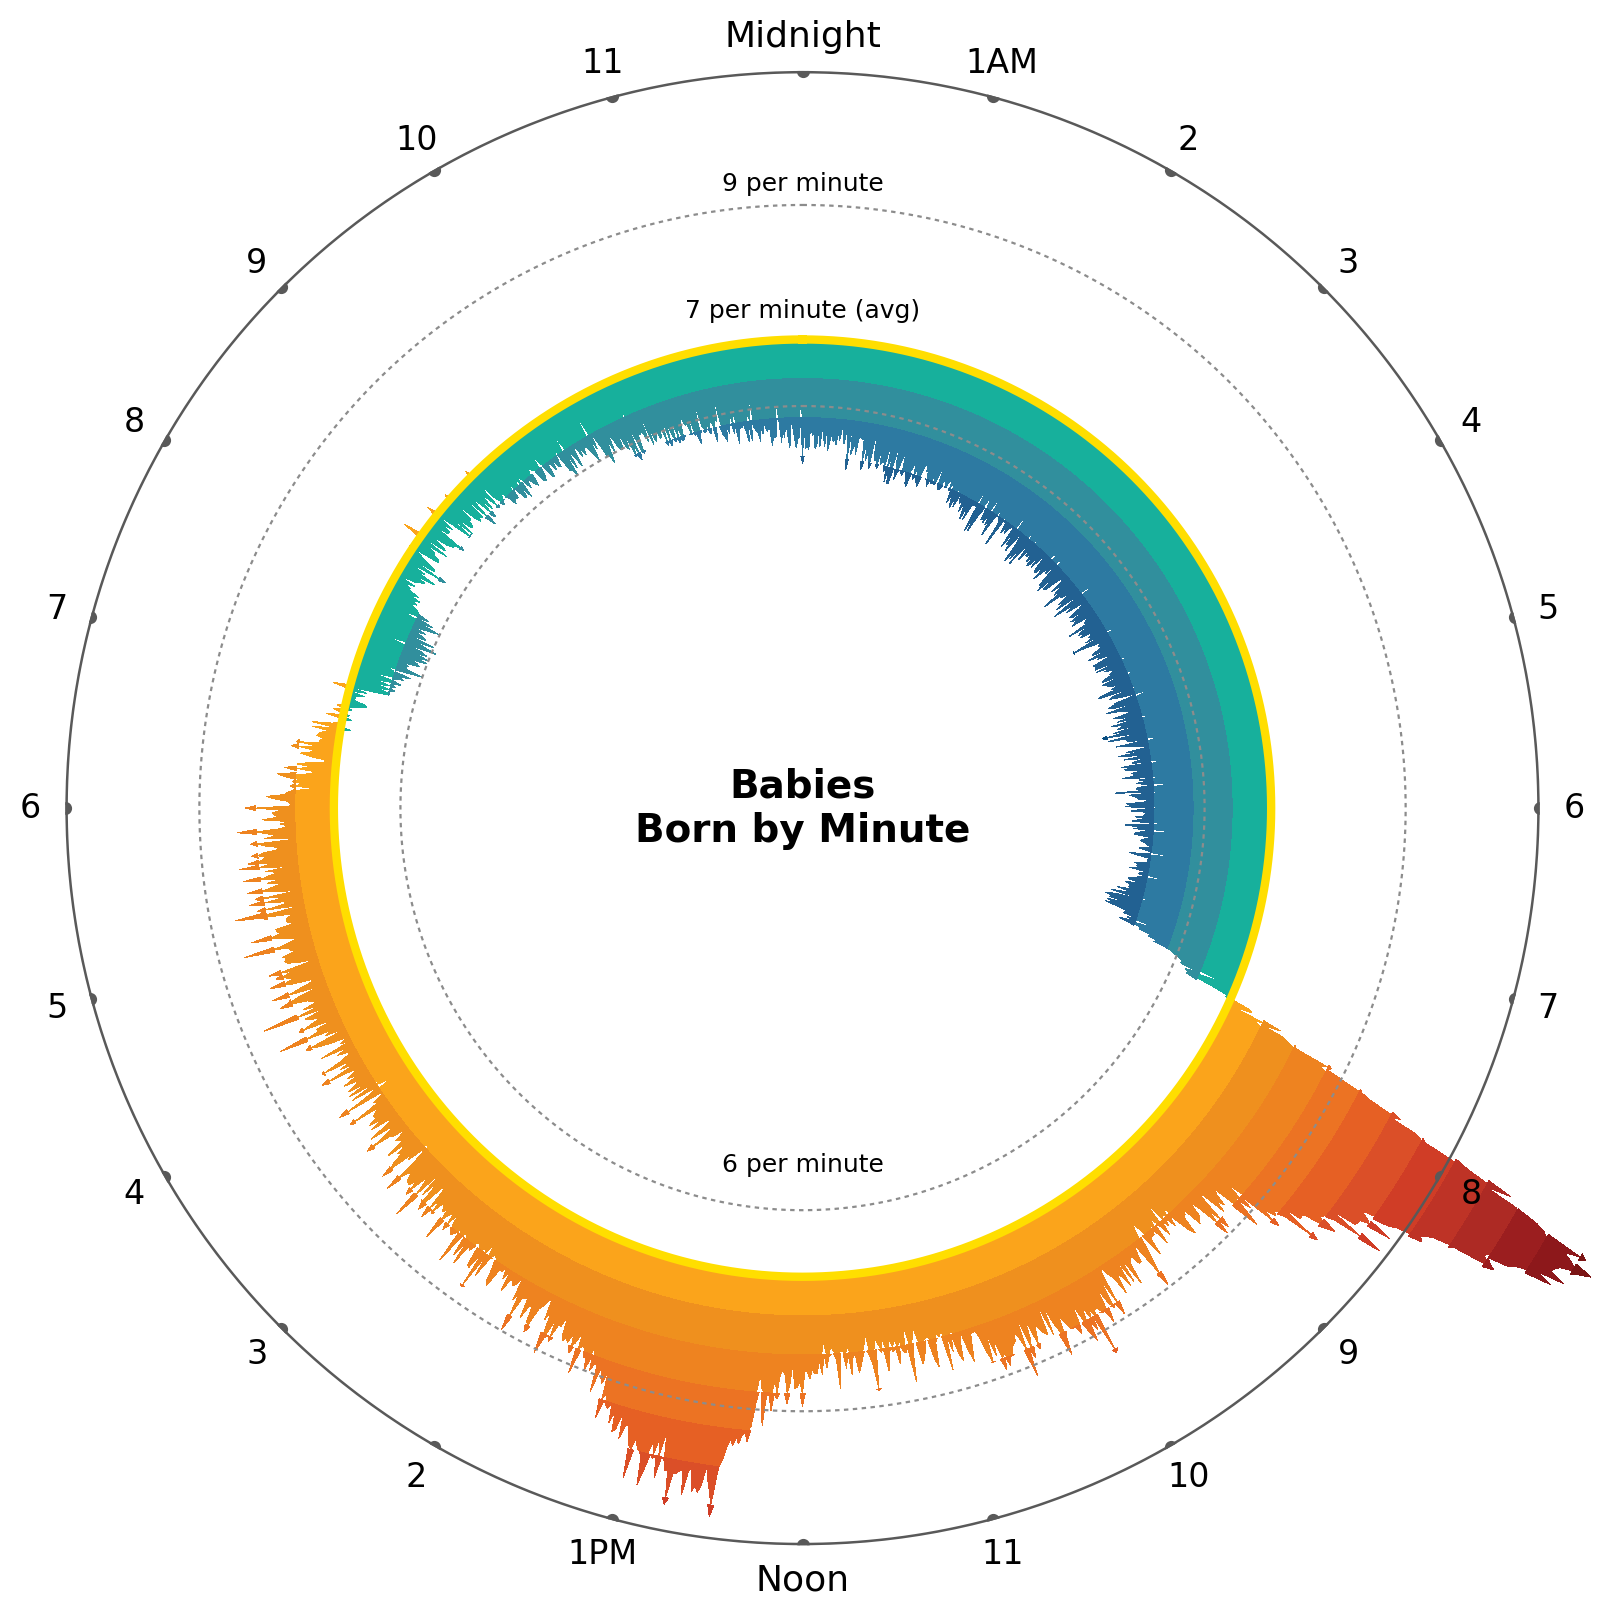

In [ ]:
# Assignment 4, Name: Osama Khadim, ID: 201938750
# Answer 1 (100 Points)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["patch.antialiased"] = False

df = pd.read_csv("births.csv")

cols = {c.lower(): c for c in df.columns}

def _find_any(substrs):
    for k, orig in cols.items():
        if any(s in k for s in substrs):
            return orig
    return None

hour_col = _find_any(["hour"])
minute_col = _find_any(["minute", "min"])
time_col = _find_any(["time"])
dt_col = _find_any(["datetime", "date_time", "timestamp", "date time"])

if hour_col is not None and minute_col is not None:
    hour = pd.to_numeric(df[hour_col], errors="coerce")
    minute = pd.to_numeric(df[minute_col], errors="coerce")

elif time_col is not None:
    t = df[time_col]
    if np.issubdtype(t.dtype, np.number):
        s = t.astype("Int64").astype(str).str.zfill(4)
        dt = pd.to_datetime(s, format="%H%M", errors="coerce")
    else:
        s = t.astype(str).str.strip()

        # Normalized "H:M" / "HH:MM" / "HH:MM:SS" -> "HH:MM:SS", I did this to resolve an error.
        parts = s.str.split(":", expand=True)
        if parts.shape[1] >= 2:
            hh = parts[0].str.zfill(2)
            mm = parts[1].str.zfill(2)
            ss = parts[2].fillna("0").str.zfill(2) if parts.shape[1] >= 3 else "00"
            s_norm = hh + ":" + mm + ":" + ss
            dt = pd.to_datetime(s_norm, format="%H:%M:%S", errors="coerce")
        else:
            dt = pd.to_datetime(s, format="%H%M", errors="coerce")

    hour = dt.dt.hour
    minute = dt.dt.minute

elif dt_col is not None:
    dt = pd.to_datetime(df[dt_col], errors="coerce")
    hour = dt.dt.hour
    minute = dt.dt.minute

else:
    raise ValueError("Could not find time columns. Run: print(df.columns)")

mask = hour.notna() & minute.notna()
hour = hour[mask].astype(int)
minute = minute[mask].astype(int)

minute_of_day = (hour * 60 + minute).astype(int)
minute_of_day = minute_of_day[(minute_of_day >= 0) & (minute_of_day < 1440)]

counts = minute_of_day.value_counts().reindex(range(1440), fill_value=0).sort_index()
babies_per_minute = counts.to_numpy() / 365.0
avg = minute_of_day.shape[0] / (365.0 * 1440.0)
colors_below = ["#17B09C", "#318F9D", "#2D7AA2", "#226192", "#094E81"]
colors_above = ["#FBA41B", "#EF901E", "#EE8320", "#EC7323", "#E66024", "#DB4F28",
                "#D03D26", "#BE3326", "#AD2A24", "#9B1E1F", "#8D181B", "#7B1515"]

theta = np.linspace(0, 2*np.pi, 1440, endpoint=False)
theta_c = np.r_[theta, theta[0]]
vals_c = np.r_[babies_per_minute, babies_per_minute[0]]

avg_line = np.full_like(theta_c, avg, dtype=float)
step = avg * 0.25 / 3.0

fig = plt.figure(figsize=(8, 8), facecolor="white", dpi=200)
ax = plt.subplot(111, polar=True)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.grid(False)
ax.set_yticks([])
ax.spines["polar"].set_visible(False)

vmax = float(np.nanmax(vals_c))
# Below-average bands 
n_below = int(np.ceil(avg / step))
for k in range(n_below):
    upper = avg - k * step
    lower = max(avg - (k + 1) * step, 0.0)
    col = colors_below[min(k, len(colors_below) - 1)]

    m = vals_c < upper
    r1 = np.full_like(vals_c, upper)
    r2 = np.where(m, np.maximum(vals_c, lower), upper)

    ax.fill_between(
        theta_c, r1, r2, where=m,
        color=col, linewidth=0, edgecolor="none",
        zorder=1, clip_on=False, interpolate=True,
        antialiased=False, rasterized=True
    )

# Above-average bands 
n_above = int(np.ceil(max(vmax - avg, 0.0) / step))
for k in range(n_above):
    lower = avg + k * step
    upper = avg + (k + 1) * step
    col = colors_above[min(k, len(colors_above) - 1)]

    m = vals_c > lower
    r1 = np.full_like(vals_c, lower)
    r2 = np.where(m, np.minimum(vals_c, upper), lower)

    ax.fill_between(
        theta_c, r1, r2, where=m,
        color=col, linewidth=0, edgecolor="none",
        zorder=1, clip_on=False, interpolate=True,
        antialiased=False, rasterized=True
    )

# Average line
ax.plot(theta_c, avg_line, color="#FFDE00", linewidth=3, zorder=5, clip_on=False)

# Dashed circles at 6 and 9
theta_circle = np.linspace(0, 2*np.pi, 800)
for r in (6.0, 9.0):
    ax.plot(theta_circle, np.full_like(theta_circle, r),
            color="0.55", linewidth=0.8, linestyle=(0, (2, 2)), zorder=2)

# Custom angular axis at r=11 with dot ticks
axis_r = 11.0
ax.set_ylim(0, axis_r)
ax.plot(theta_circle, np.full_like(theta_circle, axis_r),
        color="0.35", linewidth=1.8, zorder=6)

hours = np.arange(24)
theta_h = 2*np.pi*hours/24
ax.scatter(theta_h, np.full(24, axis_r), s=14, color="0.35", zorder=7)

labels = ["Midnight", "1AM", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11",
          "Noon", "1PM", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11"]
ax.set_xticks(theta_h)
ax.set_xticklabels(labels)
ax.tick_params(axis="x", pad=2, labelsize=12, labelrotation=0)

for t in ax.get_xticklabels():
    if t.get_text() in ("Midnight", "Noon"):
        t.set_fontsize(13)

ax.text(0.5, 0.5, "Babies\nBorn by Minute",
        transform=ax.transAxes, ha="center", va="center",
        fontsize=14, fontweight="bold")

avg_lbl = int(round(avg))
ax.text(0, 9.15, "9 per minute", ha="center", va="bottom", fontsize=9)
ax.text(0, avg + 0.25, f"{avg_lbl} per minute (avg)", ha="center", va="bottom", fontsize=9)
ax.text(np.pi, 5.5, "6 per minute", ha="center", va="bottom", fontsize=9)

plt.tight_layout(pad=0.4)
plt.show()